In [64]:
!pip install deap

In [65]:
import random
import numpy
from deap import base
from deap import creator
from deap import algorithms
from deap import tools

In [66]:
fileName = '/content/f1_l-d_kp_10_269'
capacidade = 269
optimalSolution = 295


In [67]:
# Leitura
peso = []
custo = []
with open(fileName) as f:
  # Igonora a primera linha
    next(f)
  # Começa a çeitura a partir da segunda linha
    for line in f:
        V, W = line.split()
        peso.append(int(W))
        custo.append(int(V))

In [68]:
# Função Fitness
# Com framework DEAP, deixar uma vírgula para
# garantir o padrão multiobjetibo
def fitness_function(solucao) :
  fitness = 0
  soma_capacidade = 0
  for i in range(len(solucao)) :
    if solucao[i] == 1 :
      fitness += custo[i]
      soma_capacidade += peso[i]
  if soma_capacidade > capacidade:
    #Aplica penalização
    fitness = 0
  return fitness, # Não esquecer de deixar a vírgula

In [69]:
# Gera o objetivo toolbox responsável por registrar as configurações do framework
toolbox = base.Toolbox()

# Tipo de fitness (Maximização ou Minimização)
creator.create("Maximization", base.Fitness, weights=(1.0,))
creator.create("Cromossomo", list, fitness=creator.Maximization)

# Construir o cromossomo
toolbox.register("atributo", random.randint,0,1)
toolbox.register("solucaoFinal", tools.initRepeat, creator.Cromossomo, toolbox.atributo, n=len(custo))
toolbox.register("Populacao", tools.initRepeat, list, toolbox.solucaoFinal)

# Cadastrar operadores
# Função Fitness
toolbox.register("evaluate", fitness_function)

# Cruzamento
toolbox.register("mate", tools.cxOnePoint)

# Mutação
toolbox.register("mutate", tools.mutFlipBit, indpb=0.05)

# Seleção
toolbox.register("select", tools.selTournament, tournsize=3)



/usr/local/lib/python3.12/dist-packages/deap/creator.py:185: RuntimeWarning: A class named 'Maximization' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "
/usr/local/lib/python3.12/dist-packages/deap/creator.py:185: RuntimeWarning: A class named 'Cromossomo' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "


In [70]:
# Gera o Algoritmo Genético com a estrutura e operadores cadastrados
pop = toolbox.Populacao(n=30)
prob_cx = 0.8
prob_mt = 0.1
nger = 100
hof = tools.HallOfFame(10)

# Gera o formato de análise estatística
st = tools.Statistics(key=lambda ind: ind.fitness.values)
st.register("max", numpy.max)
st.register("avg", numpy.mean)


In [71]:
# Executa o AG
finalPop, log = algorithms.eaSimple(pop, toolbox, prob_cx, prob_mt, nger, st, hof, verbose=False)


In [72]:
finalPop

[[0, 1, 0, 0, 0, 1, 0, 1, 1, 1],
 [0, 1, 0, 0, 0, 1, 0, 1, 1, 1],
 [0, 1, 0, 0, 0, 1, 0, 1, 1, 1],
 [0, 1, 0, 0, 0, 1, 0, 1, 1, 1],
 [0, 1, 0, 0, 0, 1, 0, 1, 1, 1],
 [0, 1, 0, 0, 0, 1, 0, 1, 1, 1],
 [0, 1, 0, 0, 0, 1, 0, 1, 1, 1],
 [0, 1, 0, 0, 0, 1, 0, 1, 1, 1],
 [0, 1, 0, 0, 0, 1, 0, 1, 1, 1],
 [0, 1, 0, 0, 0, 1, 0, 1, 1, 1],
 [0, 1, 0, 0, 0, 1, 0, 1, 1, 1],
 [0, 1, 0, 0, 0, 1, 0, 1, 1, 1],
 [0, 1, 0, 0, 0, 1, 0, 1, 1, 1],
 [0, 1, 0, 0, 0, 1, 0, 1, 1, 1],
 [0, 1, 0, 0, 0, 1, 0, 1, 1, 1],
 [0, 1, 0, 0, 0, 1, 0, 1, 1, 1],
 [0, 1, 0, 0, 0, 1, 0, 1, 1, 1],
 [0, 1, 0, 0, 0, 1, 0, 1, 1, 1],
 [0, 1, 0, 0, 0, 1, 0, 1, 1, 1],
 [0, 1, 0, 0, 0, 1, 0, 1, 1, 1],
 [0, 1, 0, 0, 0, 1, 0, 1, 1, 1],
 [0, 1, 0, 0, 0, 1, 0, 1, 1, 1],
 [0, 1, 0, 0, 0, 1, 0, 1, 1, 1],
 [0, 1, 0, 0, 0, 1, 0, 1, 1, 1],
 [0, 1, 0, 0, 0, 1, 0, 1, 1, 1],
 [0, 1, 0, 0, 0, 1, 0, 1, 1, 1],
 [0, 1, 0, 0, 0, 1, 0, 1, 1, 1],
 [0, 1, 0, 0, 0, 1, 0, 1, 1, 1],
 [0, 1, 0, 0, 0, 1, 0, 1, 1, 1],
 [0, 1, 0, 0, 0, 1, 0, 1, 1, 1]]

In [73]:
# Selecionar o melhor indivíduo final
melhorSolucao = tools.selBest(finalPop, k=5)
# print(f'{melhorSolucao[0]} - {melhorSolucao[0].fitness.values}')
for ind in melhorSolucao:
  print(f'{ind} - {ind.fitness.values}')

[0, 1, 0, 0, 0, 1, 0, 1, 1, 1] - (293.0,)
[0, 1, 0, 0, 0, 1, 0, 1, 1, 1] - (293.0,)
[0, 1, 0, 0, 0, 1, 0, 1, 1, 1] - (293.0,)
[0, 1, 0, 0, 0, 1, 0, 1, 1, 1] - (293.0,)
[0, 1, 0, 0, 0, 1, 0, 1, 1, 1] - (293.0,)


In [74]:
melhorSolucao[0].fitness.values

(293.0,)

In [75]:
# Percorre as melhores soluções armazenadas com HallOfFame
for best in hof:
  print(f'{best} - {best.fitness.values}')

[0, 1, 0, 0, 0, 1, 0, 1, 1, 1] - (293.0,)
[0, 0, 0, 0, 0, 1, 0, 1, 1, 1] - (283.0,)
[0, 0, 1, 0, 0, 0, 0, 1, 1, 1] - (280.0,)
[0, 1, 1, 0, 0, 1, 0, 0, 1, 1] - (279.0,)
[0, 0, 1, 0, 0, 1, 0, 0, 1, 1] - (269.0,)
[0, 1, 1, 0, 0, 1, 0, 1, 0, 1] - (255.0,)
[0, 1, 0, 0, 0, 0, 1, 1, 1, 1] - (251.0,)
[1, 1, 0, 1, 1, 0, 0, 0, 1, 1] - (246.0,)
[0, 1, 0, 0, 0, 0, 0, 1, 1, 1] - (243.0,)
[1, 1, 0, 1, 0, 0, 0, 0, 1, 1] - (242.0,)


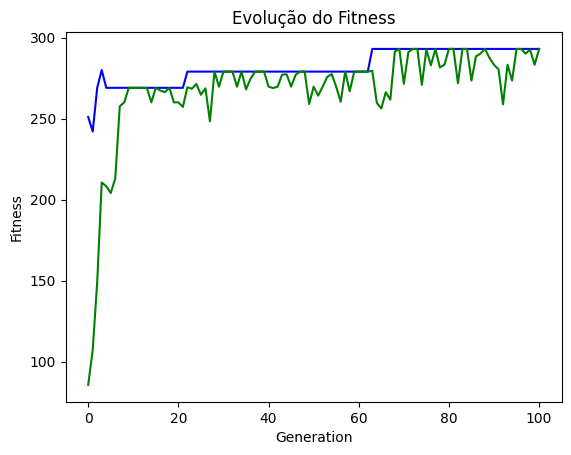

In [76]:
# Plotagem das melhores soluções x média das populações
import matplotlib.pyplot as plt

maxFit, meanFit= log.select("max", "avg")
plt.plot(maxFit, color='blue')
plt.plot(meanFit, color='green')
plt.xlabel('Generation')
plt.ylabel('Fitness')
plt.title('Evolução do Fitness')
plt.show()


In [77]:
meanFit

[np.float64(85.66666666666667),
 np.float64(107.23333333333333),
 np.float64(149.23333333333332),
 np.float64(210.53333333333333),
 np.float64(208.33333333333334),
 np.float64(204.06666666666666),
 np.float64(213.06666666666666),
 np.float64(257.6),
 np.float64(260.03333333333336),
 np.float64(269.0),
 np.float64(269.0),
 np.float64(269.0),
 np.float64(269.0),
 np.float64(269.0),
 np.float64(260.03333333333336),
 np.float64(269.0),
 np.float64(267.3333333333333),
 np.float64(266.3),
 np.float64(269.0),
 np.float64(260.03333333333336),
 np.float64(260.03333333333336),
 np.float64(257.2),
 np.float64(269.3333333333333),
 np.float64(268.43333333333334),
 np.float64(271.3333333333333),
 np.float64(264.7),
 np.float64(268.7),
 np.float64(248.26666666666668),
 np.float64(279.0),
 np.float64(269.7),
 np.float64(279.0),
 np.float64(279.0),
 np.float64(279.0),
 np.float64(269.7),
 np.float64(279.0),
 np.float64(268.03333333333336),
 np.float64(274.53333333333336),
 np.float64(279.0),
 np.float6